# Plot distributions of the data

In [2]:
import os

In [3]:
import yaml
import torch
from pathlib import Path
from osgeo import gdal
from tqdm.notebook import tqdm
gdal.UseExceptions() # Enable gdal error messages. 

cfg = yaml.safe_load(open('../runs/unet/data_v1_4/config/config.yaml', 'r')) # for all data
cfg['path_train_split_csv'] = '../' + cfg['path_train_split_csv']# adjust for relative path of this notebook.
cfg['path_val_split_csv'] = '../' + cfg['path_val_split_csv']
cfg['path_test_split_csv'] = '../' + cfg['path_test_split_csv']
cfg['path_all_split_csv'] = '../' + cfg['path_all_split_csv']
print(f"data_root: {cfg['data_root']} '\npath_melt {cfg['path_melt']}")

In [ ]:
from hrmelt.dataset import HRMeltDataset
cfg['img_size'] = (2863, 1633)
cfg['normalize_inputs'] = False
cfg['split_cfg'] = 'csv' # Load data split from csv file
cfg['in_keys'] = []
cfg['in_keys_static'] = ['landmask'] # code requires at least one in_key 

: 

In [ ]:
from hrmelt.eval.benchmark import HRMeltDatasetPredictions

####
# Change split here
split = 'test'
#
####
dataset = HRMeltDatasetPredictions(cfg=cfg,
                    split=split,
                    verbose=False,
                    model_keys=[],
                    paths_predictions=[],
                    sort=True)

print('Number of complete entries in dataset: ',len(dataset))

: 

In [39]:
inputs, targets, targets_mask, meta = dataset.__getitem__(idx=0)

In [40]:
from torch.utils.data import DataLoader

cfg['batch_size'] = 8
loader_args = dict(batch_size=cfg['batch_size'],
                    num_workers=cfg['num_workers'],
                    pin_memory=True)
dataloader = DataLoader(dataset, shuffle=False, drop_last=False, 
                            **loader_args)

In [41]:
from datetime import datetime
import numpy as np

# Compute total meltwater in image per day.
device = 'cuda'

# Deactivate normalization of targets in dataloader 
dataset.cfg['normalize_melt'] = False

# Initialize running sums
n_days = len(dataset) # 12*8 # 
total_meltwater_per_day = torch.zeros(n_days, dtype=dataset.dtype)
n_valid_pixels_per_day = torch.zeros(n_days, dtype=dataset.dtype)
timestamps_per_day = np.zeros(n_days,dtype="datetime64[ns]")

count = 0
with tqdm(total=len(dataset),unit='img') as pbar:
    for i, batch in enumerate(dataloader):
        inputs, targets, targets_mask, meta = batch
        batch_size = len(inputs)
        targets = targets.to(device=device, dtype=dataset.dtype)
        targets_mask = targets_mask.to(device=device, dtype=dataset.dtype)
        
        # Get timestamps
        timestamps = [Path(path_melt).stem for path_melt in meta['path_melt']] # e.g., '2017_08_23'
        timestamps = [datetime.strptime(timestamp, "%Y_%m_%d") for timestamp in timestamps]

        # Apply targets_mask to and target (1=invalid)
        targets = targets * (1-targets_mask)
        n_valid_pixels = torch.sum(1-targets_mask, axis=(-2,-1)).squeeze() # dims: (batch_size, 1).squeeze() -> (batch_size)

        # Compute total observed meltwater per day, i.e., sum of all fractional meltwater values that are in valid locations
        total_meltwater = torch.sum(targets, axis=(-2,-1)).squeeze() # dims: (batch_size)

        timestamps_per_day[count:count+batch_size] = np.array(timestamps)
        total_meltwater_per_day[count:count+batch_size] = total_meltwater
        n_valid_pixels_per_day[count:count+batch_size] = n_valid_pixels
        
        count += batch_size
        pbar.update(inputs.shape[0])
        if count == n_days: # for debugging
            break

  0%|          | 0/389 [00:00<?, ?img/s]

In [42]:
n_img_pixels = np.asarray(cfg['img_size']).prod()
valid_observations_per_day = n_valid_pixels_per_day / n_img_pixels # Valid observations per day (as fraction of total image)
average_meltwater_per_day = total_meltwater_per_day / n_valid_pixels_per_day # Average meltwater fraction per valid pixel

In [43]:
import pandas as pd
# Convert to pandas dataframe for easier handling of time stamps
df = pd.DataFrame(index=timestamps_per_day)
df['total_meltwater_per_day'] = total_meltwater_per_day
df['n_valid_pixels_per_day'] = n_valid_pixels_per_day
df['valid_observations_per_day'] = valid_observations_per_day
df['average_meltwater_per_day'] = average_meltwater_per_day
df.head()

,total_meltwater_per_day,n_valid_pixels_per_day,valid_observations_per_day,average_meltwater_per_day
2017-04-05,300.239990,742477.0,0.158809,0.000404
2017-04-17,391.570007,742477.0,0.158809,0.000527
2017-04-29,3520.449951,742477.0,0.158809,0.004741
2017-05-11,64571.667969,742477.0,0.158809,0.086968
2017-05-23,229140.046875,742477.0,0.158809,0.308616


In [44]:
from hrmelt.utils.plotting import split_axes

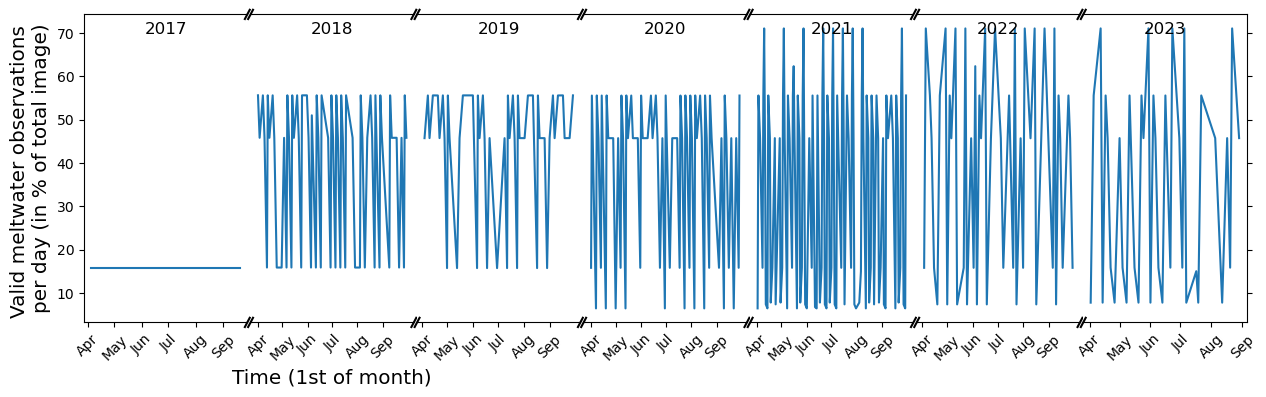

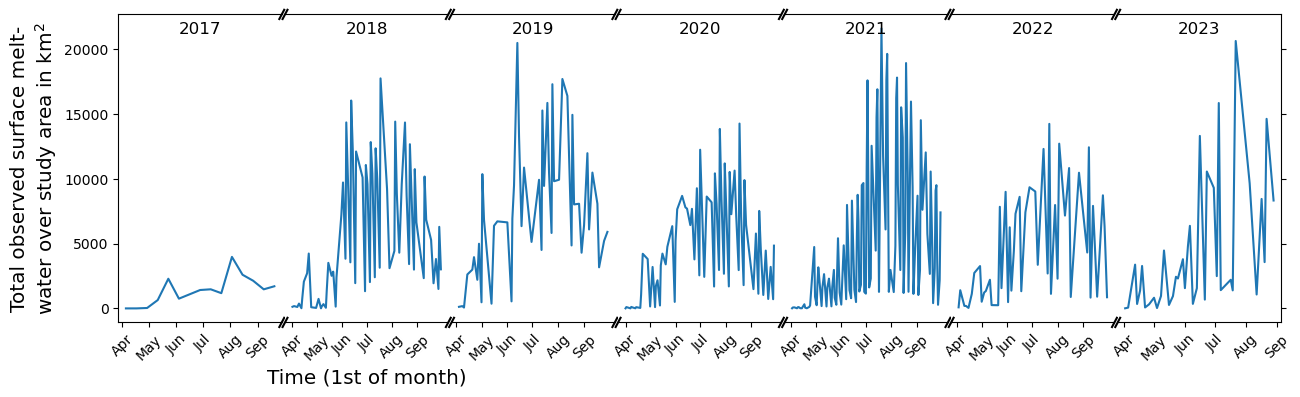

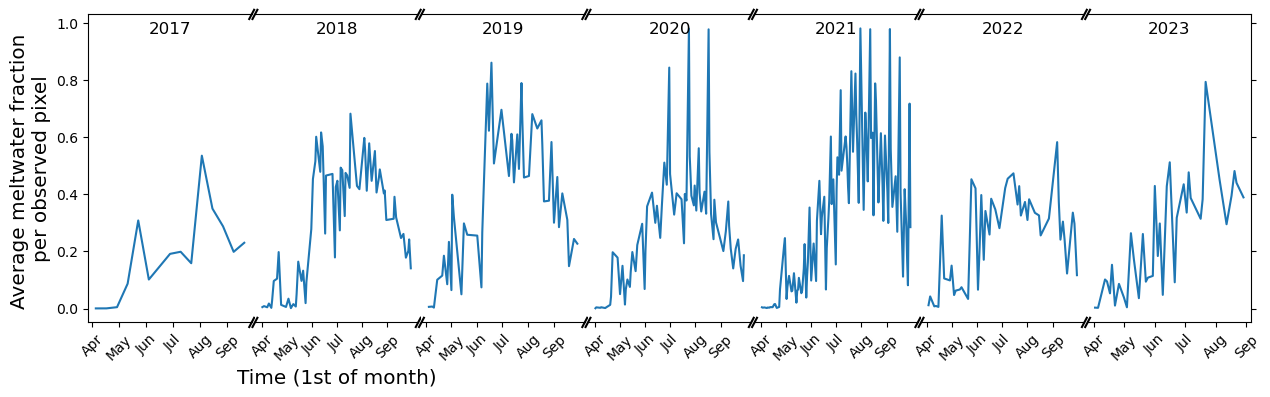

In [45]:
"""
Plot meltwater statistics per day over the full observation time
"""
import matplotlib.pylab as plt
import numpy as np
import matplotlib.dates as mdates

keys = ['valid_observations_per_day', 'total_meltwater_per_day', 'average_meltwater_per_day']

for key in keys:
    filename = '_'.join(key.split('_')[:-2]) + '.png'
    filepath_to_save = f'../references/figures/data_exploration/{cfg["data_key"]}/{split}/per_day/{filename}'

    years = df.index.year.unique()
    n_years = len(years)
    fig, axs = plt.subplots(1, n_years, sharey=True, facecolor='w',figsize=(15,4))

    # Plot the data of each year
    for ax, yr in zip(axs, years):
        df_yr = df[df.index.year == yr]
        if key == 'valid_observations_per_day':
            ax.plot(df_yr.index, df_yr.valid_observations_per_day*100)
        elif key == 'total_meltwater_per_day':
            # multiply with 100*100 to convert from fraction per 100m^2 pixel to fraction per m^2
            # divide by 1000*1000 to convert from m^2 to km^2
            ax.plot(df_yr.index, df_yr.total_meltwater_per_day*100*100/1000/1000)
        elif key == 'average_meltwater_per_day':
            ax.plot(df_yr.index, df_yr.average_meltwater_per_day)
        else:
            raise NotImplementedError(f'Given key ({key}) is invalid.')

    axs = split_axes(axs)

    # Modify axis settings
    for ax, yr in zip(axs,years):
        ax.set_title(yr, y=1.0, pad=-14)
        # Remove ticks outside of data range
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(df.index.month.unique().min(),df.index.month.unique().max()+1,1)))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.tick_params(axis='x', labelrotation=45)
        #ax.set_ylim((0.,100.))

    axs[1].set_xlabel('Time (1st of month)', fontsize='x-large') # Time in YYYY-MM
    if key == 'valid_observations_per_day':
        axs[0].set_ylabel('Valid meltwater observations \nper day (in % of total image)', fontsize='x-large')
    elif key == 'total_meltwater_per_day':
        axs[0].set_ylabel('Total observed surface melt-\nwater over study area in '+r'km$^2$', fontsize='x-large')
    elif key == 'average_meltwater_per_day':
        axs[0].set_ylabel('Average meltwater fraction \nper observed pixel', fontsize='x-large')

    if filepath_to_save is not None:
        Path(filepath_to_save).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(filepath_to_save)

    plt.show()
    plt.close()


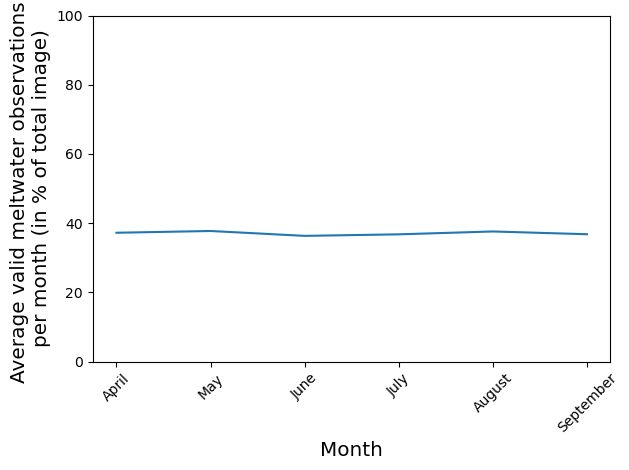

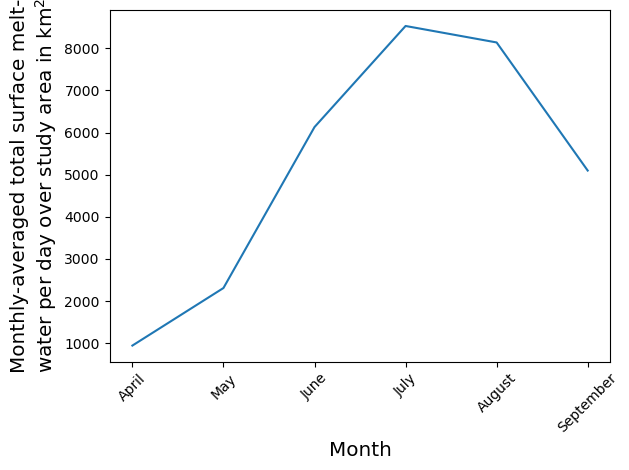

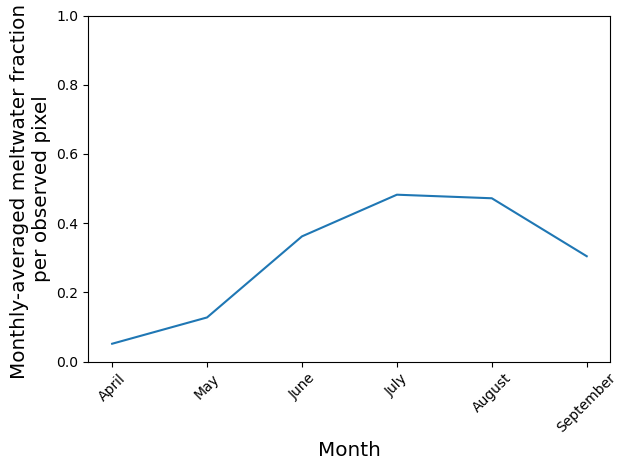

In [46]:
"""
Plot meltwater statistics per **month**
"""

keys = ['valid_observations_per_day', 'total_meltwater_per_day', 'average_meltwater_per_day']

for key in keys:
    filename = '_'.join(key.split('_')[:-2]) + '.png'
    filepath_to_save = f'../references/figures/data_exploration/{cfg["data_key"]}/{split}/per_month/{filename}'

    fig, ax = plt.subplots(1, 1)
    
    df_mon_avg = df.groupby(df.index.month).mean()
    df_mon_avg.index = pd.to_datetime(df_mon_avg.index, format='%m')
    if key == 'valid_observations_per_day':
        yaxis_value = df_mon_avg.valid_observations_per_day*100
    elif key == 'total_meltwater_per_day':
        yaxis_value = df_mon_avg.total_meltwater_per_day*100*100/1000/1000
    elif key == 'average_meltwater_per_day':
        yaxis_value = df_mon_avg.average_meltwater_per_day
    else:
        raise NotImplementedError(f'Given key ({key}) is invalid.')

    ax.plot(df_mon_avg.index.month_name(), yaxis_value)#, marker='X', linestyle='-', color='black', label='targets')

    # Modify axis settings
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_xlabel('Month', fontsize='x-large') # Time in YYYY-MM
    if key == 'valid_observations_per_day':
        ax.set_ylim((0.,100.))
        ax.set_ylabel('Average valid meltwater observations \nper month (in % of total image)', fontsize='x-large')
    elif key == 'total_meltwater_per_day':
        ax.set_ylabel('Monthly-averaged total surface melt-\nwater per day over study area in '+r'km$^2$', fontsize='x-large')
    elif key == 'average_meltwater_per_day':
        ax.set_ylim((0.,1.))
        ax.set_ylabel('Monthly-averaged meltwater fraction \nper observed pixel', fontsize='x-large')

    plt.tight_layout()
    if filepath_to_save is not None:
        Path(filepath_to_save).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(filepath_to_save)

    plt.show()
    plt.close()


In [47]:
df_yr_avg = df.groupby(df.index.year).mean()
df_yr_avg.index

Index([2017, 2018, 2019, 2020, 2021, 2022, 2023], dtype='int32')

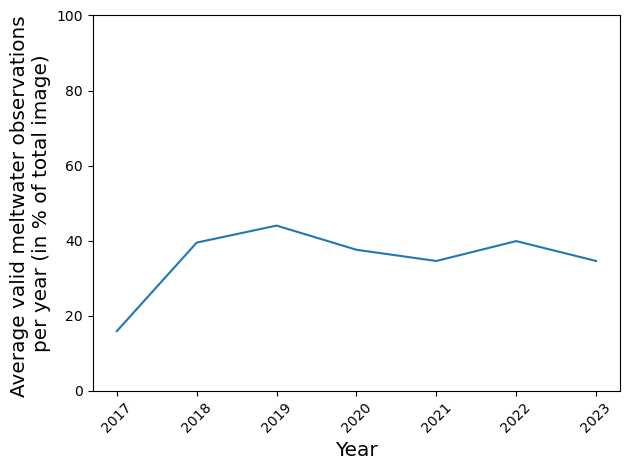

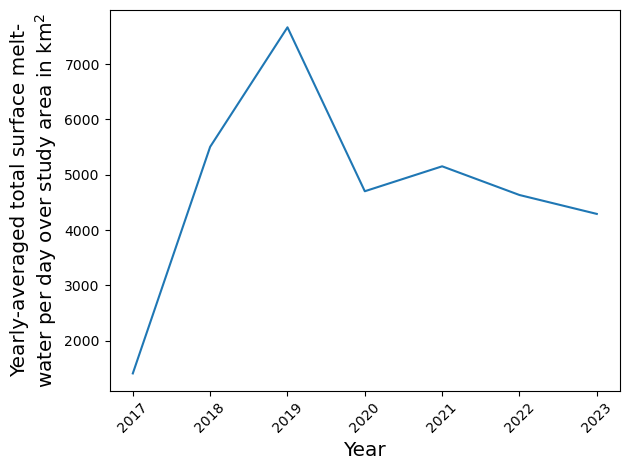

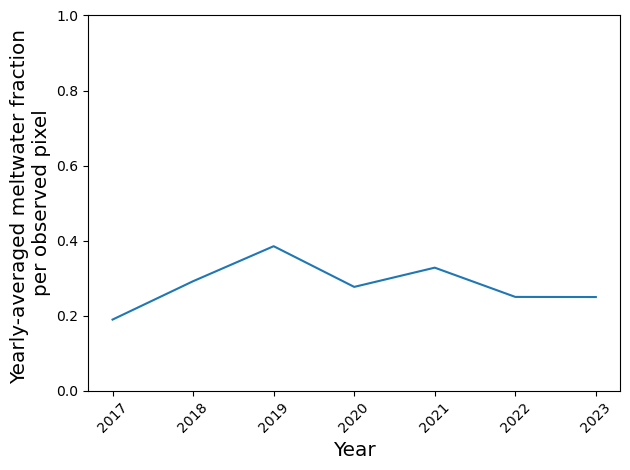

In [48]:
"""
Plot meltwater statistics per **year**
"""

keys = ['valid_observations_per_day', 'total_meltwater_per_day', 'average_meltwater_per_day']

for key in keys:
    filename = '_'.join(key.split('_')[:-2]) + '.png'
    filepath_to_save = f'../references/figures/data_exploration/{cfg["data_key"]}/{split}/per_year/{filename}'

    fig, ax = plt.subplots(1, 1)
    
    df_yr_avg = df.groupby(df.index.year).mean()
    df_yr_avg.index = pd.to_datetime(df_yr_avg.index, format='%Y')
    if key == 'valid_observations_per_day':
        yaxis_value = df_yr_avg.valid_observations_per_day*100
    elif key == 'total_meltwater_per_day':
        yaxis_value = df_yr_avg.total_meltwater_per_day*100*100/1000/1000
    elif key == 'average_meltwater_per_day':
        yaxis_value = df_yr_avg.average_meltwater_per_day
    else:
        raise NotImplementedError(f'Given key ({key}) is invalid.')

    ax.plot(df_yr_avg.index.year, yaxis_value)#, marker='X', linestyle='-', color='black', label='targets')

    # Modify axis settings
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_xlabel('Year', fontsize='x-large') # Time in YYYY-MM
    if key == 'valid_observations_per_day':
        ax.set_ylim((0.,100.))
        ax.set_ylabel('Average valid meltwater observations \nper year (in % of total image)', fontsize='x-large')
    elif key == 'total_meltwater_per_day':
        ax.set_ylabel('Yearly-averaged total surface melt-\nwater per day over study area in '+r'km$^2$', fontsize='x-large')
    elif key == 'average_meltwater_per_day':
        ax.set_ylim((0.,1.))
        ax.set_ylabel('Yearly-averaged meltwater fraction \nper observed pixel', fontsize='x-large')

    plt.tight_layout()
    if filepath_to_save is not None:
        Path(filepath_to_save).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(filepath_to_save)

    plt.show()
    plt.close()


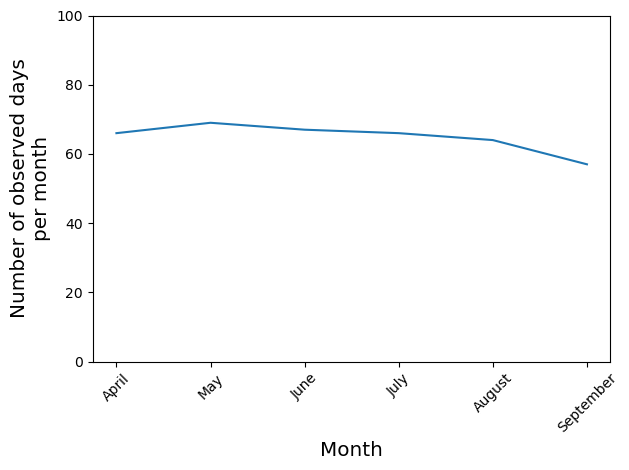

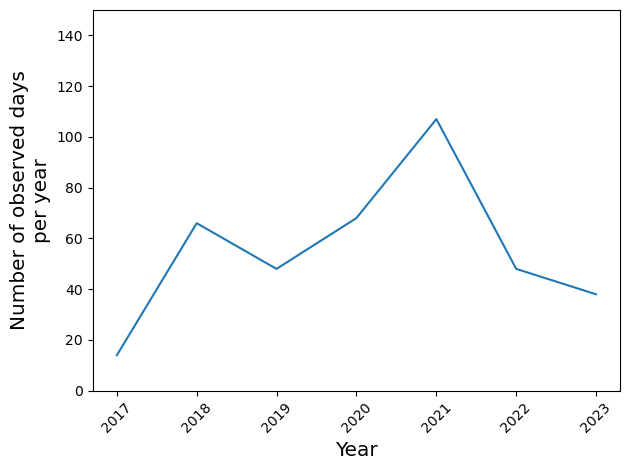

In [49]:
# Plot number of observed days per month

"""
Plot meltwater statistics per **month**
"""

filename = 'observed_days.png'

for timeframe in ['month', 'year']:
    filepath_to_save = f'../references/figures/data_exploration/{cfg["data_key"]}/{split}/per_{timeframe}/{filename}'

    fig, ax = plt.subplots(1, 1)

    if timeframe == 'month':
        count = df.groupby(df.index.month).count()[df.keys()[0]]
        count.index = pd.to_datetime(count.index, format='%m')
        ax.plot(count.index.month_name(), count.values)#, marker='X', linestyle='-', color='black', label='targets')
        ax.set_xlabel('Month', fontsize='x-large') # Time in YYYY-MM
        ax.set_ylim((0,100))

    elif timeframe == 'year':
        count = df.groupby(df.index.year).count()[df.keys()[0]]
        count.index = pd.to_datetime(count.index, format='%Y')
        ax.plot(count.index, count.values)#, marker='X', linestyle='-', color='black', label='targets')
        ax.set_xlabel('Year', fontsize='x-large') # Time in YYYY-MM
        ax.set_ylim((0,150))

    # Modify axis settings
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylabel(f'Number of observed days\nper {timeframe}', fontsize='x-large')

    plt.tight_layout()
    if filepath_to_save is not None:
        Path(filepath_to_save).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(filepath_to_save)

    plt.show()
    plt.close()


Year 2017 months: Index(['April', 'May', 'June', 'July', 'August', 'September'], dtype='object') count: [3 2 2 2 3 2]
Year 2018 months: Index(['April', 'May', 'June', 'July', 'August', 'September'], dtype='object') count: [11 12 11 11 12  9]
Year 2019 months: Index(['April', 'May', 'June', 'July', 'August', 'September'], dtype='object') count: [8 6 9 9 8 8]
Year 2020 months: Index(['April', 'May', 'June', 'July', 'August', 'September'], dtype='object') count: [11 12 10 12 12 11]
Year 2021 months: Index(['April', 'May', 'June', 'July', 'August', 'September'], dtype='object') count: [17 19 17 19 17 18]
Year 2022 months: Index(['April', 'May', 'June', 'July', 'August', 'September'], dtype='object') count: [8 9 9 7 6 9]
Year 2023 months: Index(['April', 'May', 'June', 'July', 'August'], dtype='object') count: [8 9 9 6 6]


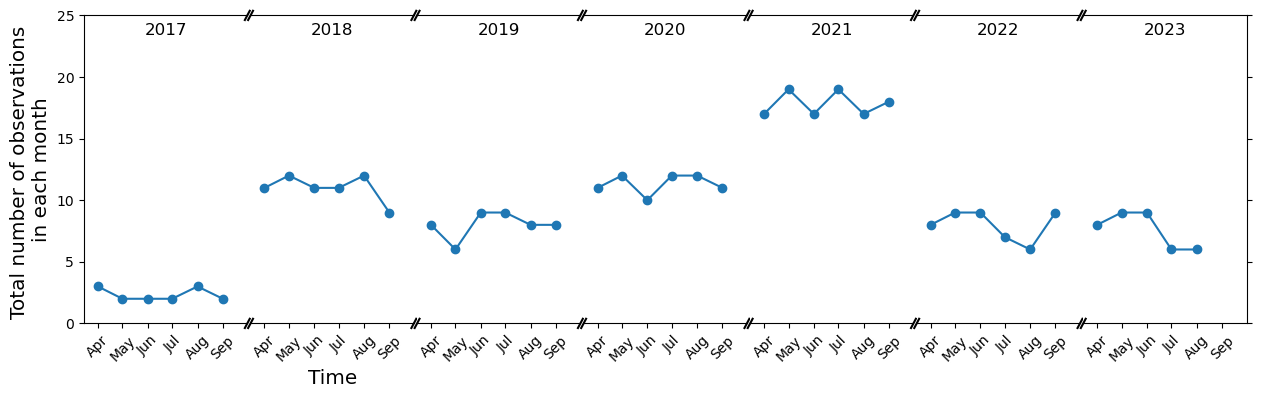

In [50]:
"""
Plot the number of observations in each month over over the full observation time
"""
from matplotlib.ticker import MaxNLocator

filename = 'total_observed_days.png'
filepath_to_save = f'../references/figures/data_exploration/{cfg["data_key"]}/{split}/per_month/{filename}'

years = df.index.year.unique()
n_years = len(years)
fig, axs = plt.subplots(1, n_years, sharey=True, facecolor='w',figsize=(15,4))


# Plot the data of each year
for ax, yr in zip(axs, years):
    df_yr = df[df.index.year == yr]
    count = df_yr.groupby(df_yr.index.month).count()[df_yr.keys()[0]]
    count.index = pd.to_datetime(count.index, format='%m')
    ax.plot(count.index, count.values, 'o', color='tab:blue')
    ax.plot(count.index, count.values, color='tab:blue')
    print(f'Year {yr} months: {count.index.month_name()} count: {count.values}')

axs = split_axes(axs)

# Modify axis settings
for ax, yr in zip(axs,years):
    ax.set_title(yr, y=1.0, pad=-14)
    # Remove ticks outside of data range
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(df.index.month.unique().min(),df.index.month.unique().max()+1,1)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True,steps=[1, 2, 5, 10]))
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylim((0.,25.))
    ax.set_xlim((np.datetime64(f'{count.index.year.unique()[0]}-03-15'), np.datetime64(f'{count.index.year.unique()[0]}-10-01')))

axs[1].set_xlabel('Time', fontsize='x-large') # Time in YYYY-MM
axs[0].set_ylabel('Total number of observations \nin each month', fontsize='x-large')

if filepath_to_save is not None:
    Path(filepath_to_save).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(filepath_to_save)

plt.show()
plt.close()
